In [2]:
import numpy as np
import pandas as pd
from IPython.display import display
import warnings
import platform
import matplotlib.pyplot as plt

# 출력 설정
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams[
        'font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 참고: seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


In [3]:
# 컬럼 정보 간단 표현
def check_basic_info(df, df_name, exclude_cols=None):
    
    print(f"\n{'='*80}")
    print(f"{df_name}의 컬럼 정보 / 결측치 확인 정보 요약")
    print(f"{'='*80}\n")


    # 제외할 컬럼 반영
    df_copied = df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')

    # dict, list, set 같은 해시 불가능 값이 들어있는 컬럼은 문자열로 변환
    for col in df_copied.columns:
        try:
            df_copied[col].nunique(dropna=True)
        except TypeError:
            df_copied[col] = df_copied[col].astype(str)
    
    # 1. 전체 요약
    overview_df = pd.DataFrame({
        '항목': ['행 개수', '열 개수', '중복 행 개수'],
        '값': [df_copied.shape[0], df_copied.shape[1], df_copied.duplicated().sum()]
    })
    
    # 2. 컬럼별 요약
    summary_df = pd.DataFrame({
        '데이터타입': df_copied.dtypes.astype(str),
        '행 개수': df_copied.count(),
        '행 비율(%)': (df_copied.count() / len(df) * 100).round(2),
        '결측치 개수': df_copied.isnull().sum(),
        '결측치 비율(%)': (df_copied.isnull().sum() / len(df) * 100).round(2),
        '고유값 개수': df_copied.nunique(dropna=True)
    })
    
    # 3. 보기 좋게 정렬
    summary_df = summary_df.sort_values(
        by=['결측치 개수', '고유값 개수'],
        ascending=[False, False]
    )
    
    print("[전체 요약]")
    display(overview_df)
    
    print("[컬럼별 요약]")
    display(summary_df)

    print("[테이블 요약]")
    display(df.head())

In [4]:
# ============================================================
# 1. 원본 데이터 로드
# ============================================================
df = pd.read_csv('../../../integrated/data/transcript_portfolio_profile.csv')

# 테이블 복제
# informational은 completed 개념이 없으니 제거하고 시작
# 필요시 그냥 df2 = df.copy() 사용
df2 = df[df['offer_type'] != 'informational'].copy()
# df2 = df.copy()
check_basic_info(df2, 'transcript_portfolio')


transcript_portfolio의 컬럼 정보 / 결측치 확인 정보 요약

[전체 요약]


,항목,값
0,행 개수,280071
1,열 개수,20
2,중복 행 개수,0


[컬럼별 요약]


,데이터타입,행 개수,행 비율(%),결측치 개수,결측치 비율(%),고유값 개수
event_reward,float64,33182,11.85,246889,88.15,4
amount,float64,138953,49.61,141118,50.39,5103
offer_id,str,141118,50.39,138953,49.61,8
offer_reward,float64,141118,50.39,138953,49.61,4
difficulty,float64,141118,50.39,138953,49.61,4
channels,str,141118,50.39,138953,49.61,4
duration,float64,141118,50.39,138953,49.61,3
offer_type,str,141118,50.39,138953,49.61,2
web,float64,141118,50.39,138953,49.61,2
mobile,float64,141118,50.39,138953,49.61,2


[테이블 요약]


,customer_id,event,time,offer_id,amount,event_reward,offer_type,offer_reward,difficulty,duration,channels,web,email,mobile,social,gender,age,income,became_member_on,profile_missing
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,0,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,NaN,bogo,5.0,5.0,7.0,"['web', 'email', 'mobile']",1.0,1.0,1.0,0.0,F,75.0,100000.0,2017-05-09,1
1,a03223e636434f42ac4c3df47e8bac43,offer received,0,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,NaN,discount,5.0,20.0,10.0,"['web', 'email']",1.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,0
2,e2127556f4f64592b11af22de27a7932,offer received,0,2906b810c7d4411798c6938adc9daaa5,NaN,NaN,discount,2.0,10.0,7.0,"['web', 'email', 'mobile']",1.0,1.0,1.0,0.0,M,68.0,70000.0,2018-04-26,1
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,0,fafdcd668e3743c1bb461111dcafc2a4,NaN,NaN,discount,2.0,10.0,10.0,"['web', 'email', 'mobile', 'social']",1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,0
4,68617ca6246f4fbc85e91a2a49552598,offer received,0,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN,NaN,bogo,10.0,10.0,5.0,"['web', 'email', 'mobile', 'social']",1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,0


In [5]:
# received 분리
received = (
    df2[df2['event'] == 'offer received'][
        [
            'customer_id', 'offer_id', 'time',
            'offer_type', 'offer_reward', 'difficulty', 'duration',
            'web', 'email', 'mobile', 'social'
        ]
    ]
    .copy()
    .rename(columns={'time': 'time_received'})
)

# completed 분리
completed = (
    df2[df2['event'] == 'offer completed'][
        ['customer_id', 'offer_id', 'time']
    ]
    .copy()
    .rename(columns={'time': 'time_completed'})
)

print("received 행 수:", len(received))
print("completed 행 수:", len(completed))

received 행 수: 61042
completed 행 수: 33182


In [6]:
# ============================================================
# completed를 가장 최근의 유효한 received에 연결
# ============================================================
received = received.sort_values(
    ["customer_id", "offer_id", "time_received"]
).reset_index(drop=True)

completed = completed.sort_values(
    ["customer_id", "offer_id", "time_completed"]
).reset_index(drop=True)

# received 행 번호 만들기
received["received_idx"] = received.index

In [7]:
match_rows = []

# customer_id + offer_id 기준으로 completed를 하나씩 확인
for (customer_id, offer_id), completed_group in completed.groupby(["customer_id", "offer_id"]):
    
    # 같은 customer_id, offer_id의 received만 따로 가져오기
    received_group = received[
        (received["customer_id"] == customer_id) &
        (received["offer_id"] == offer_id)
    ].copy()
    
    # 이미 매칭된 received는 다시 쓰지 않기 위한 집합
    used_received = set()
    
    # completed 시간만 하나씩 확인
    for completed_time in completed_group["time_completed"]:
        
        # 조건에 맞는 received 후보 찾기
        candidates = received_group[
            (received_group["time_received"] <= completed_time) &
            ((completed_time - received_group["time_received"]) <= received_group["duration"] * 24) &
            (~received_group["received_idx"].isin(used_received))
        ].copy()
        
        # 후보가 없으면 다음 completed로
        if len(candidates) == 0:
            continue
        
        # 후보 중 가장 최근 received 선택
        best_received = candidates.sort_values("time_received", ascending=False).iloc[0]
        
        # 매칭 결과 저장
        match_rows.append({
            "received_idx": best_received["received_idx"],
            "time_completed": completed_time
        })
        
        # 사용한 received는 다시 못 쓰게 저장
        used_received.add(best_received["received_idx"])

# 매칭 결과 테이블
match_df = pd.DataFrame(match_rows)

In [8]:
rc = received.merge(
    match_df,
    on="received_idx",
    how='left'
)

rc["has_completed"] = rc["time_completed"].notna().astype(int)
rc["time_diff"] = rc["time_completed"] - rc["time_received"]

rc["valid_time_order"] = (
    (rc["time_diff"] >= 0)
).fillna(False).astype(int)

rc["valid_duration"] = (
    (rc["time_diff"] >= 0) &
    (rc["time_diff"] <= rc["duration"] * 24)
).fillna(False).astype(int)

rc["converted_final"] = (
    (rc["has_completed"] == 1) &
    (rc["valid_time_order"] == 1) &
    (rc["valid_duration"] == 1)
).astype(int)

rc = rc[
    [
        # 1. 고객 / 오퍼 식별
        'customer_id', 'offer_id',

        # 2. 오퍼 속성
        'offer_type', 'offer_reward', 'difficulty', 'duration',

        # 3. 채널 정보
        'web', 'email', 'mobile', 'social',

        # 4. 시간 정보
        'time_received', 'time_completed', 'time_diff',

        # 5. 판정 결과
        'has_completed', 'valid_time_order', 'valid_duration', 'converted_final'
    ]
].copy()

check_basic_info(rc, 'received + completed ')


received + completed 의 컬럼 정보 / 결측치 확인 정보 요약

[전체 요약]


,항목,값
0,행 개수,61042
1,열 개수,17
2,중복 행 개수,0


[컬럼별 요약]


,데이터타입,행 개수,행 비율(%),결측치 개수,결측치 비율(%),고유값 개수
time_completed,float64,33152,54.31,27890,45.69,120
time_diff,float64,33152,54.31,27890,45.69,41
customer_id,str,61042,100.00,0,0.00,16928
offer_id,str,61042,100.00,0,0.00,8
time_received,int64,61042,100.00,0,0.00,6
offer_reward,float64,61042,100.00,0,0.00,4
difficulty,float64,61042,100.00,0,0.00,4
duration,float64,61042,100.00,0,0.00,3
offer_type,str,61042,100.00,0,0.00,2
web,float64,61042,100.00,0,0.00,2


[테이블 요약]


,customer_id,offer_id,offer_type,offer_reward,difficulty,duration,web,email,mobile,social,time_received,time_completed,time_diff,has_completed,valid_time_order,valid_duration,converted_final
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,discount,2.0,10.0,7.0,1.0,1.0,1.0,0.0,576,576.0,0.0,1,1,1,1
1,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,bogo,5.0,5.0,5.0,1.0,1.0,1.0,1.0,408,414.0,6.0,1,1,1,1
2,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,discount,2.0,10.0,10.0,1.0,1.0,1.0,1.0,504,528.0,24.0,1,1,1,1
3,00116118485d4dfda04fdbaba9a87b5c,f19421c1d4aa40978ebb69ca19b0e20d,bogo,5.0,5.0,5.0,1.0,1.0,1.0,1.0,168,NaN,NaN,0,0,0,0
4,00116118485d4dfda04fdbaba9a87b5c,f19421c1d4aa40978ebb69ca19b0e20d,bogo,5.0,5.0,5.0,1.0,1.0,1.0,1.0,576,NaN,NaN,0,0,0,0


In [9]:
print("=" * 80)
print("기본 검증단계")
print("=" * 80)

print("received 기준 전체 건수:", len(rc))
print("completed가 붙은 건수:", rc['has_completed'].sum())
print("타임 순서가 맞는 건수:", rc['valid_time_order'].sum())
print("duration 안에 완료된 건수:", rc['valid_duration'].sum())
print("최종 전환 건수:", rc['converted_final'].sum())
print()
print("최종 전환율:", round(rc['converted_final'].mean() * 100, 2), "%")

기본 검증단계
received 기준 전체 건수: 61042
completed가 붙은 건수: 33152
타임 순서가 맞는 건수: 33152
duration 안에 완료된 건수: 33152
최종 전환 건수: 33152

최종 전환율: 54.31 %


In [10]:
offer_type_conv = (
    rc.groupby('offer_type')
      .agg(
          received_count=('customer_id', 'size'),
          converted_count=('converted_final', 'sum'),
          conversion_rate=('converted_final', 'mean')
      )
      .reset_index()
)

offer_type_conv['conversion_rate'] = (offer_type_conv['conversion_rate'] * 100).round(2)

print("=" * 80)
print("오퍼 유형별 최종 전환율")
print("=" * 80)
display(offer_type_conv)

오퍼 유형별 최종 전환율


,offer_type,received_count,converted_count,conversion_rate
0,bogo,30499,15501,50.82
1,discount,30543,17651,57.79


In [11]:
def conversion_table(df, group_col):
    result = (
        df.groupby(group_col)
          .agg(
              received_count=('customer_id', 'size'),
              converted_count=('converted_final', 'sum'),
              conversion_rate=('converted_final', 'mean')
          )
          .reset_index()
    )
    
    result['conversion_rate'] = (result['conversion_rate'] * 100).round(2)
    return result.sort_values('conversion_rate', ascending=False).reset_index(drop=True)

In [12]:
print("=" * 80)
print("offer_type별 최종 전환율")
print("=" * 80)
display(conversion_table(rc, 'offer_type'))

offer_type별 최종 전환율


,offer_type,received_count,converted_count,conversion_rate
0,discount,30543,17651,57.79
1,bogo,30499,15501,50.82


In [13]:
print("=" * 80)
print("reward별 최종 전환율")
print("=" * 80)
display(conversion_table(rc, 'offer_reward'))

reward별 최종 전환율


,offer_reward,received_count,converted_count,conversion_rate
0,3.0,7646,5108,66.81
1,2.0,15229,9209,60.47
2,5.0,22916,11899,51.92
3,10.0,15251,6936,45.48


In [14]:
print("=" * 80)
print("difficulty별 최종 전환율")
print("=" * 80)
display(conversion_table(rc, 'difficulty'))

difficulty별 최종 전환율


,difficulty,received_count,converted_count,conversion_rate
0,7.0,7646,5108,66.81
1,5.0,15248,8565,56.17
2,10.0,30480,16145,52.97
3,20.0,7668,3334,43.48


In [15]:
print("=" * 80)
print("duration별 최종 전환율")
print("=" * 80)
display(conversion_table(rc, 'duration'))

duration별 최종 전환율


,duration,received_count,converted_count,conversion_rate
0,10.0,15265,8585,56.24
1,7.0,30613,17004,55.55
2,5.0,15164,7563,49.87


In [16]:
for ch in ['web', 'email', 'mobile', 'social']:
    print("=" * 80)
    print(f"{ch} 채널 여부별 최종 전환율")
    print("=" * 80)
    display(conversion_table(rc, ch))

web 채널 여부별 최종 전환율


,web,received_count,converted_count,conversion_rate
0,1.0,53384,29517,55.29
1,0.0,7658,3635,47.47


email 채널 여부별 최종 전환율


,email,received_count,converted_count,conversion_rate
0,1.0,61042,33152,54.31


mobile 채널 여부별 최종 전환율


,mobile,received_count,converted_count,conversion_rate
0,1.0,53374,29818,55.87
1,0.0,7668,3334,43.48


social 채널 여부별 최종 전환율


,social,received_count,converted_count,conversion_rate
0,1.0,38065,21557,56.63
1,0.0,22977,11595,50.46


In [17]:
def plot_conversion_rate(df, group_col, title):
    plot_df = conversion_table(df, group_col)

    plt.figure(figsize=(8, 5))
    bars = plt.bar(plot_df[group_col].astype(str), plot_df['conversion_rate'])

    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{height:.1f}%',
            ha='center',
            va='bottom'
        )

    plt.title(title)
    plt.xlabel(group_col)
    plt.ylabel('Conversion Rate (%)')
    plt.ylim(0, plot_df['conversion_rate'].max() * 1.15)
    plt.show()

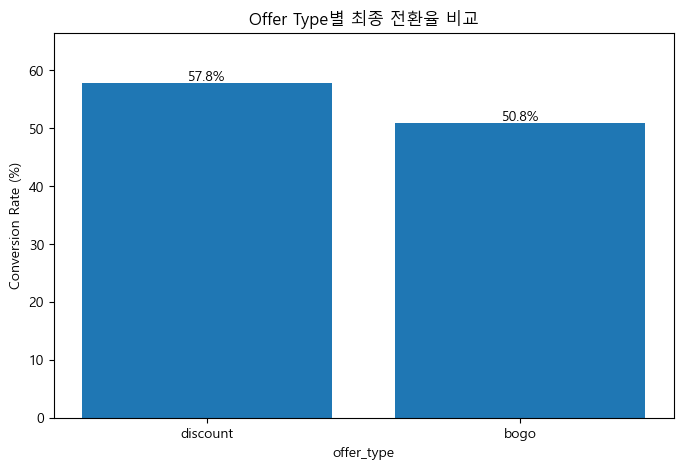

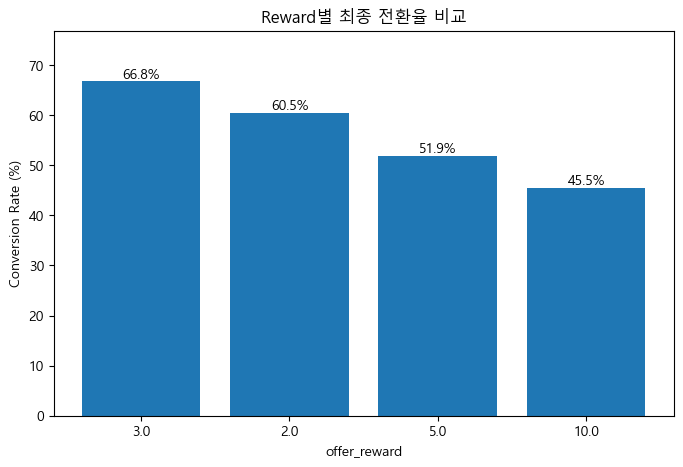

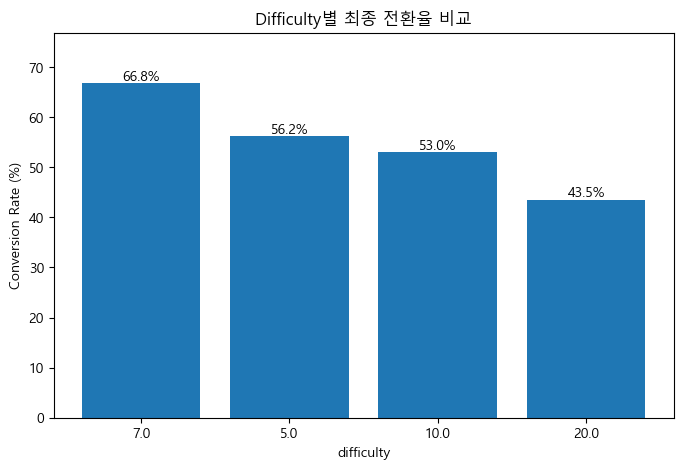

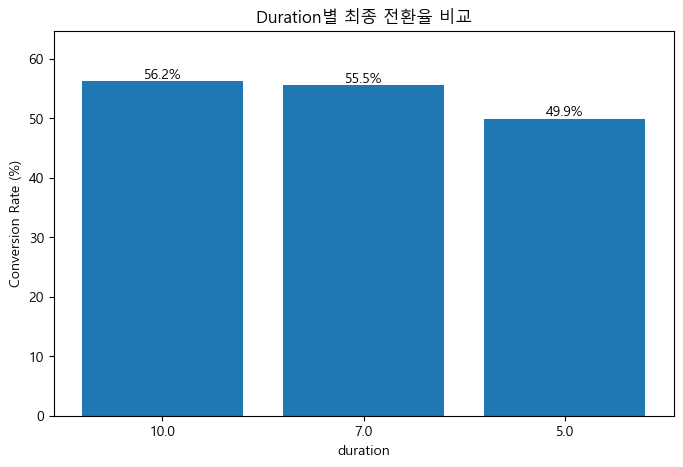

In [18]:
plot_conversion_rate(rc, 'offer_type', 'Offer Type별 최종 전환율 비교')
plot_conversion_rate(rc, 'offer_reward', 'Reward별 최종 전환율 비교')
plot_conversion_rate(rc, 'difficulty', 'Difficulty별 최종 전환율 비교')
plot_conversion_rate(rc, 'duration', 'Duration별 최종 전환율 비교')

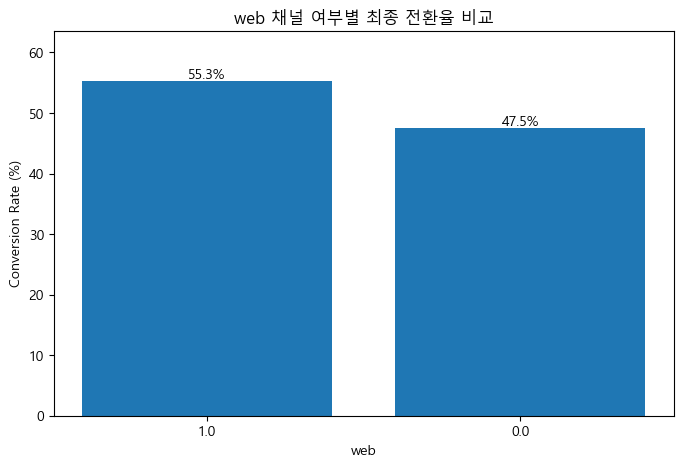

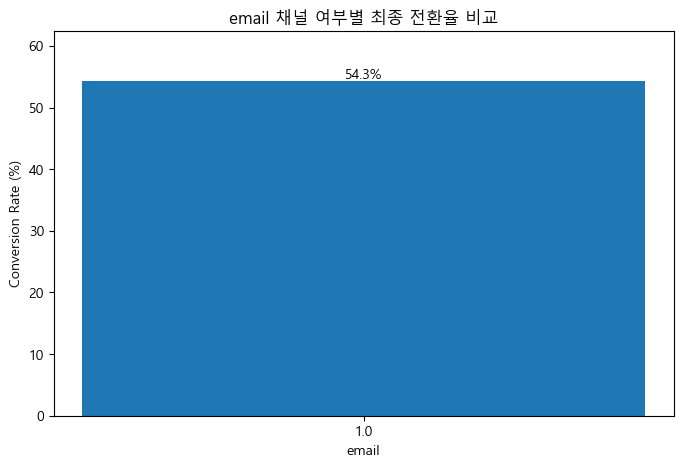

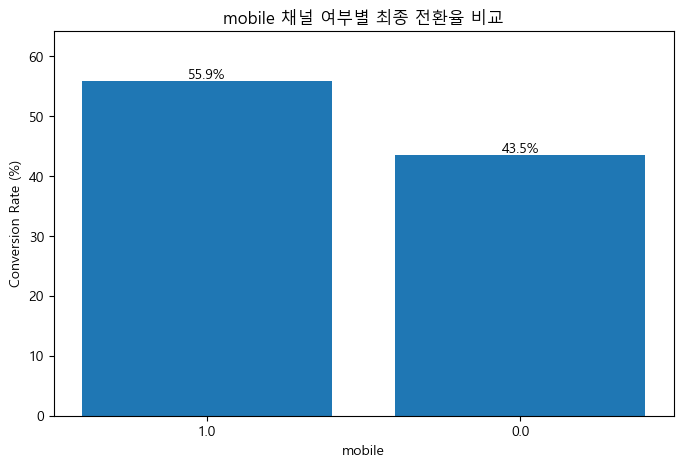

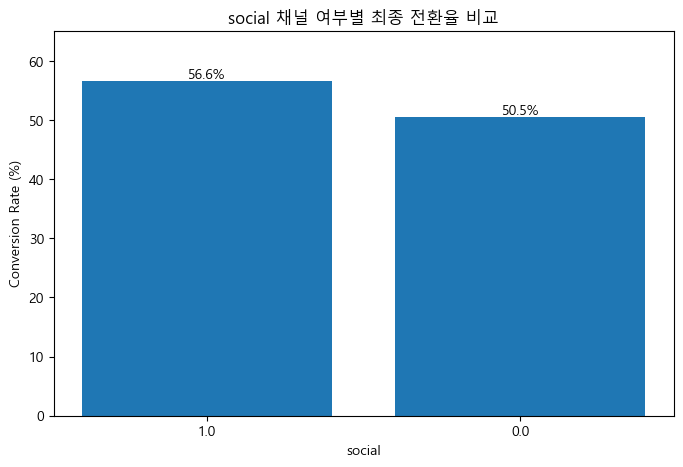

In [19]:
for ch in ['web', 'email', 'mobile', 'social']:
    plot_conversion_rate(rc, ch, f'{ch} 채널 여부별 최종 전환율 비교')

In [20]:
def channel_name(row):
    cols = ['web', 'email', 'mobile', 'social']
    active = [c for c in cols if row[c] == 1]
    return '+'.join(active) if active else 'none'

rc['channel_combo'] = rc.apply(channel_name, axis=1)

In [21]:
display(conversion_table(rc, 'channel_combo'))

,channel_combo,received_count,converted_count,conversion_rate
0,web+email+mobile+social,30407,17922,58.94
1,web+email+mobile,15309,8261,53.96
2,email+mobile+social,7658,3635,47.47
3,web+email,7668,3334,43.48


In [22]:
channel_result = conversion_table(rc, 'channel_combo')

display(channel_result.head(10))

,channel_combo,received_count,converted_count,conversion_rate
0,web+email+mobile+social,30407,17922,58.94
1,web+email+mobile,15309,8261,53.96
2,email+mobile+social,7658,3635,47.47
3,web+email,7668,3334,43.48


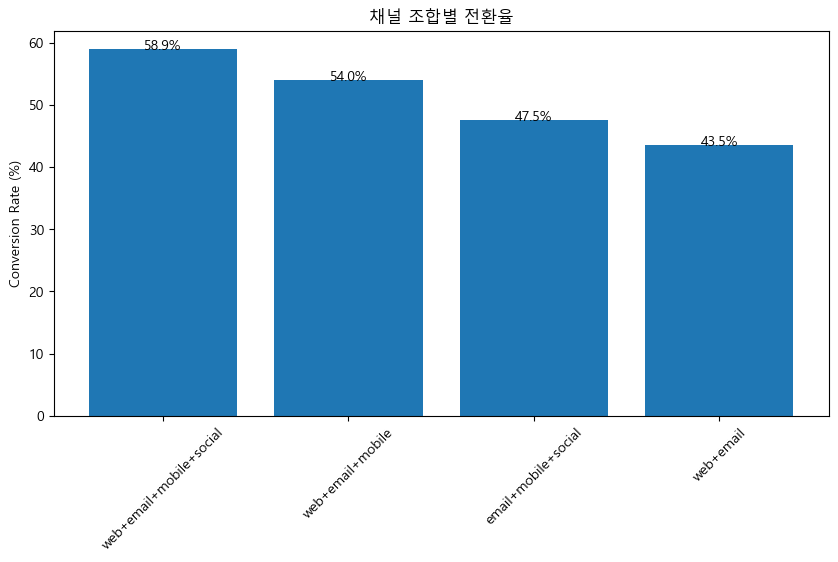

In [23]:
top_channel = channel_result.head(10)

plt.figure(figsize=(10,5))
bars = plt.bar(top_channel['channel_combo'], top_channel['conversion_rate'])

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h, f'{h:.1f}%', ha='center')

plt.xticks(rotation=45)
plt.title('채널 조합별 전환율')
plt.ylabel('Conversion Rate (%)')
plt.show()

mobile 포함 + 다채널일수록 전환율이 높다

In [24]:
rc['mobile_flag'] = rc['mobile']

display(conversion_table(rc, 'mobile_flag'))

,mobile_flag,received_count,converted_count,conversion_rate
0,1.0,53374,29818,55.87
1,0.0,7668,3334,43.48


- channel_combo = 어떤 채널 묶음인지
- received_count = 그 조합으로 받은 오퍼 수
- converted_count = 그중 최종 전환된 수
- conversion_rate = 최종 전환 비율

채널별 단순 비교를 넘어서, 실제 오퍼가 어떤 채널 조합으로 전달되었을 때 전환이 높아지는지를 보기 위해 채널 조합 변수를 새로 생성했다. 이후 조합별 received 수, converted 수, 최종 전환율을 집계해 비교

In [25]:
rc['channel_count'] = rc[['web','email','mobile','social']].sum(axis=1)

display(conversion_table(rc, 'channel_count'))

,channel_count,received_count,converted_count,conversion_rate
0,4.0,30407,17922,58.94
1,3.0,22967,11896,51.80
2,2.0,7668,3334,43.48


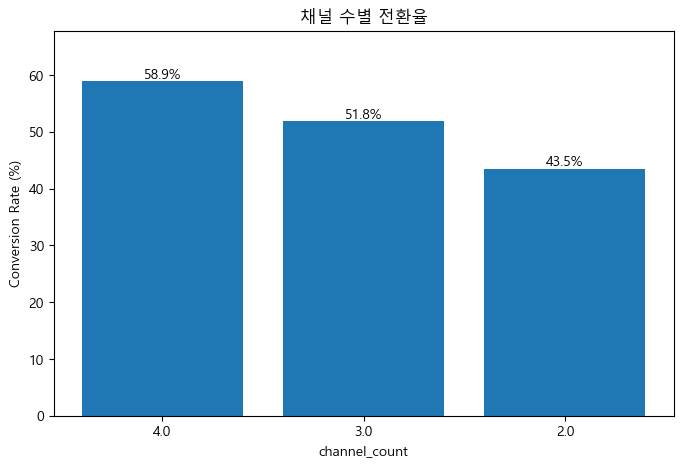

In [32]:
plot_conversion_rate(rc, 'channel_count', '채널 수별 전환율')

In [27]:
display(conversion_table(rc, ['offer_type', 'mobile']))

,offer_type,mobile,received_count,converted_count,conversion_rate
0,discount,1.0,22875,14317,62.59
1,bogo,1.0,30499,15501,50.82
2,discount,0.0,7668,3334,43.48


In [33]:
display(conversion_table(rc, 'mobile'))
display(conversion_table(rc, 'web'))
display(conversion_table(rc, 'email'))
display(conversion_table(rc, 'social'))

,mobile,received_count,converted_count,conversion_rate
0,1.0,53374,29818,55.87
1,0.0,7668,3334,43.48


,web,received_count,converted_count,conversion_rate
0,1.0,53384,29517,55.29
1,0.0,7658,3635,47.47


,email,received_count,converted_count,conversion_rate
0,1.0,61042,33152,54.31


,social,received_count,converted_count,conversion_rate
0,1.0,38065,21557,56.63
1,0.0,22977,11595,50.46


In [29]:
conversion_table(rc, ['difficulty', 'mobile'])

,difficulty,mobile,received_count,converted_count,conversion_rate
0,7.0,1.0,7646,5108,66.81
1,5.0,1.0,15248,8565,56.17
2,10.0,1.0,30480,16145,52.97
3,20.0,0.0,7668,3334,43.48


In [30]:
conversion_table(rc, 'web')

,web,received_count,converted_count,conversion_rate
0,1.0,53384,29517,55.29
1,0.0,7658,3635,47.47


In [31]:
conversion_table(rc, 'email')

,email,received_count,converted_count,conversion_rate
0,1.0,61042,33152,54.31
